[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/helvecioneto/datascience/blob/main/praticas/pratica01.ipynb)

# Aula Prática 01 — Primeiro fluxo de análise: Python e pandas na prática

**Disciplina:** Introdução à Ciência de Dados (NSA A110)
**Professor:** Helvecio Bezerra Leal Neto — Universidade Federal do Oeste do Pará
**Data:** 27/08/2026 · 19:00 às 22:00
**Nível:** Intermediário

## Por que esta aula existe

Nas aulas teóricas conversamos sobre o que é ciência de dados e quais ferramentas compõem o ecossistema Python. Hoje você vai *executar* esse ciclo do começo ao fim, em escala reduzida, no seu próprio notebook.

O fluxo que vamos percorrer é sempre o mesmo, do trabalho de bancada ao projeto industrial:

**importar → inspecionar → limpar → resumir → visualizar → interpretar**

Cada etapa tem uma ferramenta concreta associada. Ao final da aula você deve conseguir apontar, para cada linha do notebook, a que etapa do fluxo ela pertence.

## Objetivos de aprendizagem

Ao final desta prática, você será capaz de:

1. Configurar um ambiente Python reprodutível para análise de dados (bibliotecas, imports, semente aleatória).
2. Carregar um dataset real em `pandas` e realizar a inspeção inicial (`head`, `info`, `describe`, tipos e valores ausentes).
3. Diagnosticar e tratar problemas básicos de qualidade dos dados: ausentes, duplicatas e tipos incorretos.
4. Calcular e **interpretar** medidas de tendência central e dispersão (média, mediana, desvio padrão, quantis), no espírito do capítulo 5 de Grus.
5. Produzir uma visualização simples com Matplotlib e escrever, em português, o achado principal que ela sustenta.

## Pré-requisitos

- Python básico: variáveis, listas, dicionários, `for`, funções e fatiamento.
- Noção elementar de média e mediana (revisamos hoje na prática).
- Ambiente: **Google Colab** (nada a instalar) ou Jupyter local com `pandas`, `numpy`, `matplotlib` e `seaborn`.

## Regra de ouro do notebook

> Um notebook só está pronto quando roda **do zero, de cima para baixo, sem erro**.
> Antes de entregar: `Runtime → Restart and run all` (Colab) ou `Kernel → Restart & Run All` (Jupyter).

Isso não é preciosismo: é a diferença entre um resultado que outra pessoa consegue reproduzir e um número que só existiu na sua tela.

In [1]:
# ============================================================
# 1. PREPARAÇÃO DO AMBIENTE
# ============================================================
# Por que cada biblioteca:
#   pandas     -> estruturas tabulares (DataFrame); é o "Excel programável" da análise
#   numpy      -> arrays numéricos e geração de números aleatórios reprodutíveis
#   matplotlib -> biblioteca base de gráficos do ecossistema Python
#   seaborn    -> gráficos estatísticos + datasets públicos EMBUTIDOS (usaremos um deles)
#
# No Google Colab tudo isso já vem instalado. A linha abaixo garante o ambiente local.
# O -q ("quiet") só reduz o log da instalação.

%pip install pandas numpy matplotlib seaborn -q

In [2]:
# Imports: sempre no topo, sempre com os apelidos convencionais da comunidade.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reprodutibilidade: fixar a semente faz o "aleatório" ser o MESMO a cada execução.
# Sem isso, cada aluno veria números diferentes e a aula viraria uma torre de Babel.
np.random.seed(42)

# Ajustes de exibição do pandas (puramente cosméticos, mas ajudam a ler as saídas).
pd.set_option("display.max_columns", 30)      # não esconder colunas
pd.set_option("display.width", 120)           # largura da impressão no console
pd.set_option("display.float_format", "{:.2f}".format)  # 2 casas decimais

# Estilo padrão dos gráficos desta aula.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)     # proporção 16:9, boa para projetor

print("Ambiente pronto.")
print("pandas:", pd.__version__, "| numpy:", np.__version__, "| seaborn:", sns.__version__)

Ambiente pronto.
pandas: 2.2.3 | numpy: 2.1.3 | seaborn: 0.13.2


## 2. Conceito em ação: de onde vêm os dados

Um projeto de ciência de dados começa com uma pergunta e um conjunto de dados que *talvez* a responda. Hoje usaremos o dataset público **`penguins`**, embutido no seaborn: medidas corporais de 344 pinguins de três espécies coletadas nas ilhas Palmer, na Antártida, por Kristen Gorman e pela Palmer Station LTER.

Escolhemos ele por três motivos pedagógicos:

- É **público e embutido**: `sns.load_dataset` o traz sem arquivo local, sem chave de API, sem download manual.
- Tem **variáveis numéricas e categóricas** misturadas, exatamente como um CSV do mundo real.
- Tem **valores ausentes de verdade** — não inventados por nós. Você vai encontrar dado sujo já na primeira inspeção, que é o cenário honesto.

> **Nota sobre o CSV.** No mundo real você escreveria `pd.read_csv("dados.csv")`. Para tornar isso concreto, vamos gravar o dataset em CSV no disco temporário e lê-lo de volta com `read_csv` — o mesmo comando que você usará com dados próprios, sem depender de nenhum arquivo que você ainda não tem.

**Nossa pergunta de trabalho para hoje:**
> *As três espécies de pinguim se distinguem pela massa corporal? Qual delas é a mais pesada, e o quanto essa diferença é grande frente à variação dentro de cada espécie?*

In [3]:
# --- Etapa 1 do fluxo: IMPORTAR ---

# (a) Obtemos o dataset embutido no seaborn (vem da internet na 1a vez, depois fica em cache).
penguins_origem = sns.load_dataset("penguins")

# (b) Gravamos em CSV para simular a fonte típica de dados de um projeto real.
penguins_origem.to_csv("pinguins.csv", index=False)  # index=False: não gravar o índice como coluna

# (c) E lemos de volta com read_csv, que é o comando que você usará com SEUS dados.
df = pd.read_csv("pinguins.csv")

# Traduzimos os nomes das colunas para o português: um notebook lido por brasileiros
# fica mais claro assim, e renomear colunas é operação rotineira em limpeza de dados.
df = df.rename(columns={
    "species":           "especie",
    "island":            "ilha",
    "bill_length_mm":    "comprimento_bico_mm",
    "bill_depth_mm":     "profundidade_bico_mm",
    "flipper_length_mm": "comprimento_nadadeira_mm",
    "body_mass_g":       "massa_corporal_g",
    "sex":               "sexo",
})

print("Dimensões (linhas, colunas):", df.shape)

Dimensões (linhas, colunas): (344, 7)


### 2.1 Inspeção inicial: os quatro comandos que você sempre roda

Antes de calcular qualquer estatística, é preciso saber **o que** se tem em mãos. Quatro comandos respondem quase tudo:

| Comando | Pergunta que ele responde |
|---|---|
| `df.head()` | Como são as primeiras linhas? Os dados "parecem" certos? |
| `df.shape` | Quantas observações e quantas variáveis? |
| `df.info()` | Que **tipo** tem cada coluna e quantos valores **não-nulos** existem? |
| `df.describe()` | Qual a distribuição das colunas numéricas? |

Rodar esses quatro comandos leva dez segundos e evita horas de análise em cima de dado errado. É o hábito mais barato e mais rentável da profissão.

In [4]:
# --- Etapa 2 do fluxo: INSPECIONAR ---

# head(n): as n primeiras linhas. Serve para "olhar nos olhos" dos dados.
df.head()

,especie,ilha,comprimento_bico_mm,profundidade_bico_mm,comprimento_nadadeira_mm,massa_corporal_g,sexo
0,Adelie,Torgersen,39.10,18.70,181.00,3750.00,Male
1,Adelie,Torgersen,39.50,17.40,186.00,3800.00,Female
2,Adelie,Torgersen,40.30,18.00,195.00,3250.00,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.70,19.30,193.00,3450.00,Female


In [23]:
# info(): raio-X estrutural do DataFrame.
# Leia com atenção a coluna "Non-Null Count": ela denuncia os valores ausentes.
df.describe()

,comprimento_bico_mm,profundidade_bico_mm,comprimento_nadadeira_mm,massa_corporal_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.23,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


**Interpretando a saída do `info()`**

Três leituras importantes:

1. **344 entradas** no total (índice de 0 a 343).
2. As colunas numéricas (`comprimento_bico_mm`, `profundidade_bico_mm`, `comprimento_nadadeira_mm`, `massa_corporal_g`) são `float64`; as categóricas (`especie`, `ilha`, `sexo`) são `object`, que é como o pandas rotula texto.
3. **Nem toda coluna tem 344 valores não-nulos.** As quatro medidas corporais têm 342 e a coluna `sexo` tem 333. Ou seja: existem linhas com medidas faltando e um número maior de linhas sem o sexo registrado.

Isso é o mundo real batendo à porta. Antes de decidir o que fazer com esses buracos, precisamos medi-los.

In [6]:
# Contagem de ausentes por coluna, em valor absoluto e em percentual.
ausentes = pd.DataFrame({
    "ausentes": df.isna().sum(),
    "percentual": (df.isna().mean() * 100).round(2),
})

# Ordenamos do pior para o melhor: a coluna mais problemática aparece no topo.
ausentes.sort_values("ausentes", ascending=False)

,ausentes,percentual
sexo,11,3.20
profundidade_bico_mm,2,0.58
comprimento_bico_mm,2,0.58
comprimento_nadadeira_mm,2,0.58
massa_corporal_g,2,0.58
ilha,0,0.00
especie,0,0.00


In [7]:
# Quantas linhas estão COMPLETAMENTE íntegras (sem nenhum ausente)?
linhas_completas = df.dropna().shape[0]
print(f"Linhas totais.......: {len(df)}")
print(f"Linhas sem ausentes.: {linhas_completas}")
print(f"Perda se removermos.: {len(df) - linhas_completas} linhas "
      f"({(1 - linhas_completas/len(df))*100:.1f}%)")

# Duplicatas exatas também são um problema clássico de qualidade.
print(f"\nLinhas duplicadas...: {df.duplicated().sum()}")

Linhas totais.......: 344
Linhas sem ausentes.: 333
Perda se removermos.: 11 linhas (3.2%)

Linhas duplicadas...: 0


### 2.2 Conceito em ação: limpar é decidir, não é apagar

Diante de valores ausentes existem três estratégias, e **nenhuma delas é neutra**:

- **Remover as linhas** (`dropna`): simples e honesto, mas descarta informação. Aceitável quando a perda é pequena e os ausentes parecem espalhados ao acaso.
- **Imputar** (preencher com média, mediana, moda ou modelo): preserva o tamanho da amostra, mas **inventa números**, o que reduz artificialmente a variabilidade observada.
- **Manter e tratar explicitamente**: usar métodos que lidam com ausência, ou analisar o padrão da ausência como informação em si.

Grus insiste no ponto: *"no mundo real, os dados são sujos"*, e verificar valores ausentes, outliers e dados inválidos é parte inseparável da análise, não um preâmbulo chato [Data science do zero · pág. 254].

**Nossa decisão para hoje, declarada por escrito:** removeremos as 2 linhas sem medidas corporais (perda de 0,6%, irrelevante para a nossa pergunta) e **manteremos** as linhas sem `sexo`, porque nossa pergunta é sobre espécie, não sobre sexo. Descartar 11 pinguins medidos por causa de um campo que não vamos usar seria desperdício.

> **A regra:** toda decisão de limpeza vai escrita numa célula de Markdown, com o motivo. Um notebook sem justificativa é um notebook que ninguém consegue auditar — nem você mesmo daqui a três meses.

In [8]:
# --- Etapa 3 do fluxo: LIMPAR ---

# Removemos apenas as linhas sem MEDIDAS corporais (subset restringe a checagem).
colunas_medida = ["comprimento_bico_mm", "profundidade_bico_mm",
                  "comprimento_nadadeira_mm", "massa_corporal_g"]

df_limpo = df.dropna(subset=colunas_medida).copy()  # .copy() evita o SettingWithCopyWarning

# Convertemos as colunas de texto para o tipo 'category': economiza memória
# e deixa explícito que são rótulos, não texto livre.
for coluna in ["especie", "ilha", "sexo"]:
    df_limpo[coluna] = df_limpo[coluna].astype("category")

print(f"Antes : {df.shape[0]} linhas")
print(f"Depois: {df_limpo.shape[0]} linhas  (removidas: {df.shape[0] - df_limpo.shape[0]})")
print(f"\nAusentes restantes por coluna:\n{df_limpo.isna().sum()}")

Antes : 344 linhas
Depois: 342 linhas  (removidas: 2)

Ausentes restantes por coluna:
especie                     0
ilha                        0
comprimento_bico_mm         0
profundidade_bico_mm        0
comprimento_nadadeira_mm    0
massa_corporal_g            0
sexo                        9
dtype: int64


In [9]:
# Sanidade das variáveis categóricas: quais categorias existem e com que frequência?
# Isso pega erros de digitação ("Adelie" vs "adelie") e categorias inesperadas.
for coluna in ["especie", "ilha", "sexo"]:
    print(f"--- {coluna} ---")
    print(df_limpo[coluna].value_counts(dropna=False), "\n")

--- especie ---
especie
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64 

--- ilha ---
ilha
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64 

--- sexo ---
sexo
Male      168
Female    165
NaN         9
Name: count, dtype: int64 



**Interpretando as contagens**

As categorias estão limpas: três espécies (`Adelie`, `Chinstrap`, `Gentoo`), três ilhas (`Biscoe`, `Dream`, `Torgersen`) e dois sexos, sem variações de grafia ou capitalização. Note que a amostra é **desbalanceada** — há bem mais pinguins Adelie do que Chinstrap.

Isso importa: qualquer média calculada sobre o conjunto todo será puxada na direção da espécie mais numerosa. É por isso que, daqui a pouco, vamos calcular estatísticas **por grupo**, e não só no agregado.

### 2.3 Conceito em ação: tendência central e dispersão

Duas perguntas resumem uma variável numérica:

**Onde está o centro?**
- **Média** (`mean`): soma dividida pelo número de observações. Sensível a valores extremos.
- **Mediana** (`median`): o valor do meio quando os dados são ordenados. Robusta a extremos.

Quando média e mediana se afastam muito, há assimetria ou outliers na distribuição. Compará-las é diagnóstico gratuito.

**O quanto os dados se espalham?**
- **Desvio padrão** (`std`): dispersão típica em torno da média, na mesma unidade da variável.
- **Amplitude interquartil** (IQR = Q3 − Q1): faixa onde estão os 50% centrais dos dados; robusta como a mediana.
- **Mínimo e máximo**: os extremos observados.

O `describe()` entrega quase tudo isso de uma vez só.

In [10]:
# --- Etapa 4 do fluxo: RESUMIR ---

# describe(): contagem, média, desvio padrão, mínimo, quartis e máximo das colunas numéricas.
df_limpo.describe()

,comprimento_bico_mm,profundidade_bico_mm,comprimento_nadadeira_mm,massa_corporal_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.23,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


In [11]:
# Um resumo focado na variável de interesse, com média E mediana lado a lado.
massa = df_limpo["massa_corporal_g"]

print("MASSA CORPORAL (g) — visão geral")
print(f"  n         : {massa.count()}")
print(f"  média     : {massa.mean():.1f}")
print(f"  mediana   : {massa.median():.1f}")
print(f"  desvio pad: {massa.std():.1f}")
print(f"  mínimo    : {massa.min():.1f}")
print(f"  máximo    : {massa.max():.1f}")

# Quantis e IQR: a medida de dispersão robusta.
q1, q3 = massa.quantile([0.25, 0.75])
print(f"  Q1 / Q3   : {q1:.1f} / {q3:.1f}")
print(f"  IQR       : {q3 - q1:.1f}")

# Coeficiente de variação: dispersão relativa, em %. Permite comparar variáveis
# de escalas diferentes (massa em gramas vs. bico em milímetros).
print(f"  CV        : {massa.std() / massa.mean() * 100:.1f}%")

MASSA CORPORAL (g) — visão geral
  n         : 342
  média     : 4201.8
  mediana   : 4050.0
  desvio pad: 802.0
  mínimo    : 2700.0
  máximo    : 6300.0
  Q1 / Q3   : 3550.0 / 4750.0
  IQR       : 1200.0
  CV        : 19.1%


**Interpretando o resumo da massa corporal**

- A média (≈ 4.202 g) e a mediana (≈ 4.050 g) estão próximas, mas a média é **maior**. Isso indica uma cauda à direita: existem pinguins bem pesados puxando a média para cima, e é a mediana que representa melhor o "pinguim típico".
- O desvio padrão de ≈ 802 g sobre uma média de ≈ 4.200 g dá um coeficiente de variação de ≈ 19%: dispersão considerável.
- A faixa vai de ≈ 2.700 g a ≈ 6.300 g — o pinguim mais pesado tem mais que o dobro da massa do mais leve.

**Aqui está a armadilha didática da aula.** Esse desvio padrão alto é, em grande parte, um artefato de estarmos misturando três espécies num único balde. A variação *entre* espécies está sendo lida como se fosse variação *dentro* de uma população homogênea. Um número agregado pode esconder exatamente a estrutura que interessa. Vamos desagregar.

In [12]:
# groupby: a operação mais importante do pandas na análise exploratória.
# Dividir → aplicar → combinar ("split-apply-combine").
resumo_especie = (
    df_limpo
    .groupby("especie", observed=True)["massa_corporal_g"]
    .agg(n="count", media="mean", mediana="median", desvio="std", minimo="min", maximo="max")
    .round(1)
    .sort_values("media", ascending=False)
)

resumo_especie

,n,media,mediana,desvio,minimo,maximo
especie,,,,,,
Gentoo,123,5076.00,5000.00,504.10,3950.00,6300.00
Chinstrap,68,3733.10,3700.00,384.30,2700.00,4800.00
Adelie,151,3700.70,3700.00,458.60,2850.00,4775.00


In [13]:
# Dispersão relativa DENTRO de cada espécie, para comparar com os 19% do agregado.
resumo_especie["cv_percent"] = (resumo_especie["desvio"] / resumo_especie["media"] * 100).round(1)
print(resumo_especie[["n", "media", "desvio", "cv_percent"]])

print(f"\nCV do conjunto agregado (3 espécies juntas): "
      f"{massa.std() / massa.mean() * 100:.1f}%")

             n   media  desvio  cv_percent
especie                                   
Gentoo     123 5076.00  504.10        9.90
Chinstrap   68 3733.10  384.30       10.30
Adelie     151 3700.70  458.60       12.40

CV do conjunto agregado (3 espécies juntas): 19.1%


**Interpretando o resumo por espécie**

O quadro muda completamente:

- O **Gentoo** é claramente a espécie mais pesada, com média em torno de 5.076 g, contra ≈ 3.700 g de Adelie e Chinstrap, que são praticamente equivalentes entre si.
- O coeficiente de variação **dentro** de cada espécie cai para a faixa de 8% a 10%, contra os ≈ 19% do conjunto agregado.

Essa queda é o achado metodológico da aula: **metade da "variabilidade" que víamos era, na verdade, diferença entre grupos.** Sempre que uma variável categórica relevante existe no dataset, desagregar por ela é o primeiro reflexo. O agregado não estava errado — ele estava respondendo a uma pergunta menos interessante do que a nossa.

### 2.4 Conceito em ação: visualizar para confirmar

Números resumem; gráficos revelam **forma**. Duas distribuições podem ter a mesma média e a mesma dispersão e ainda assim serem completamente diferentes — bimodal contra unimodal, simétrica contra assimétrica.

Vamos produzir dois gráficos com Matplotlib:

1. Um **histograma** da massa corporal agregada, para ver a forma da distribuição que gerou aquele desvio padrão alto.
2. Um **boxplot por espécie**, para confrontar visualmente os grupos.

Regra que vale para todo gráfico que sair deste notebook: **título, rótulos nos eixos e unidades**. Um gráfico sem eixo rotulado não comunica nada — apenas decora.

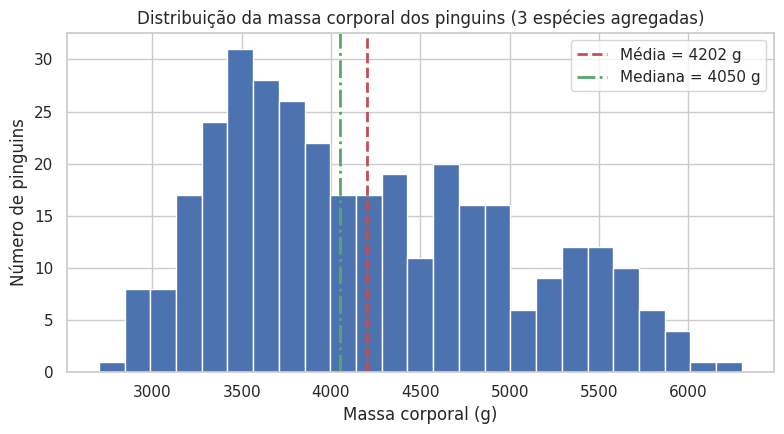

In [14]:
# --- Etapa 5 do fluxo: VISUALIZAR ---

fig, ax = plt.subplots()

ax.hist(df_limpo["massa_corporal_g"], bins=25, color="#4C72B0", edgecolor="white")

# Linhas de referência para média e mediana: tornam a assimetria visível.
ax.axvline(massa.mean(),   color="#C44E52", linestyle="--", linewidth=2,
           label=f"Média = {massa.mean():.0f} g")
ax.axvline(massa.median(), color="#55A868", linestyle="-.", linewidth=2,
           label=f"Mediana = {massa.median():.0f} g")

ax.set_title("Distribuição da massa corporal dos pinguins (3 espécies agregadas)")
ax.set_xlabel("Massa corporal (g)")
ax.set_ylabel("Número de pinguins")
ax.legend()

plt.tight_layout()
plt.show()

**Interpretando o histograma**

A distribuição agregada é visivelmente **bimodal**: há um agrupamento grande em torno de 3.500 a 4.000 g e um segundo, menor, em torno de 5.000 a 5.500 g. Não é uma curva em sino.

Isso confirma graficamente o que o `groupby` já havia sugerido: a média de 4.202 g cai num **vale** entre os dois picos, descrevendo um pinguim que quase não existe na amostra. É o caso clássico em que a média, sozinha, é uma péssima representante dos dados. O gráfico torna evidente em dois segundos o que o número escondia.

/tmp/ipykernel_2206/2598720232.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  caixas = ax.boxplot(dados_por_especie, labels=ordem, patch_artist=True, widths=0.55)


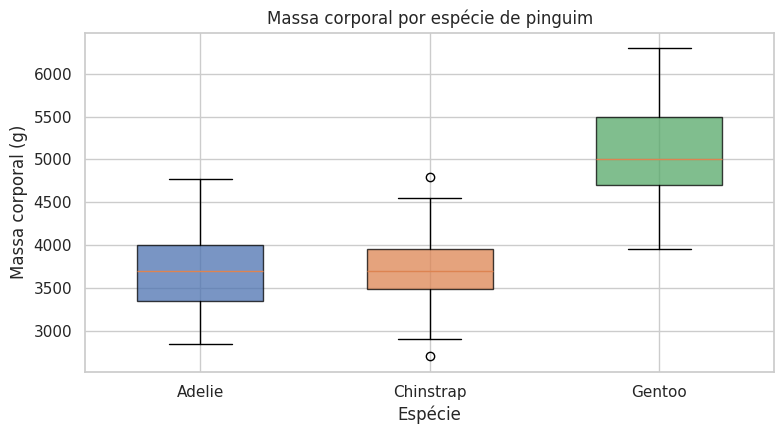

In [15]:
# Boxplot por espécie: compara centro, dispersão e outliers dos três grupos.
fig, ax = plt.subplots()

ordem = ["Adelie", "Chinstrap", "Gentoo"]
dados_por_especie = [df_limpo.loc[df_limpo["especie"] == e, "massa_corporal_g"] for e in ordem]

caixas = ax.boxplot(dados_por_especie, labels=ordem, patch_artist=True, widths=0.55)

# Uma cor por espécie, aplicada às caixas.
for caixa, cor in zip(caixas["boxes"], ["#4C72B0", "#DD8452", "#55A868"]):
    caixa.set_facecolor(cor)
    caixa.set_alpha(0.75)

ax.set_title("Massa corporal por espécie de pinguim")
ax.set_xlabel("Espécie")
ax.set_ylabel("Massa corporal (g)")

plt.tight_layout()
plt.show()

**Interpretando o boxplot — o achado principal da aula**

Escrito como você deve escrever num relatório:

> Entre os 342 pinguins com medidas completas das ilhas Palmer, a massa corporal difere de forma marcante entre espécies. O **Gentoo** apresenta massa mediana de aproximadamente 5.000 g, cerca de **1.350 g acima** das medianas de Adelie e Chinstrap, que são praticamente indistinguíveis entre si (≈ 3.700 g). A separação é tão nítida que a caixa do Gentoo (50% centrais) **não se sobrepõe** às caixas das outras duas espécies. Já Adelie e Chinstrap se sobrepõem quase integralmente: pela massa corporal, isoladamente, não é possível distingui-las.
>
> A consequência prática é que a distribuição bimodal observada no conjunto agregado corresponde à divisão Gentoo × (Adelie + Chinstrap), e não a alguma característica intrínseca de uma população única. Qualquer análise que ignore a espécie estará descrevendo um artefato de mistura.

Repare na anatomia desse parágrafo, porque é ela que você vai reproduzir nos exercícios:

1. **Contexto e tamanho da amostra** (n = 342, ilhas Palmer).
2. **Achado quantificado** (≈ 1.350 g de diferença), não "bem maior".
3. **Evidência visual citada** (caixas não se sobrepõem).
4. **Limite honesto** (Adelie e Chinstrap não se distinguem por essa variável).
5. **Consequência para a análise**.

## 3. Exercícios guiados

Os dois exercícios seguem a mesma lógica: dificuldade progressiva e sempre terminando em **interpretação escrita**. Código que produz número sem frase que explique o número não completa o exercício.

### Exercício 1 — Perfil de uma variável e diagnóstico de assimetria

**Contexto.** Você entrou como estagiário no núcleo de dados de uma secretaria estadual de meio ambiente. A equipe de biologia enviou este dataset e pediu um "perfil rápido" do **comprimento da nadadeira** (`comprimento_nadadeira_mm`) antes da reunião de amanhã.

**Tarefas:**

1. Calcule média, mediana, desvio padrão, Q1, Q3 e IQR do comprimento da nadadeira.
2. Compare média e mediana e diga se há indício de assimetria (e em qual direção).
3. Conte quantos pinguins têm nadadeira **acima** da média e quantos abaixo. Se a distribuição fosse simétrica, esses números seriam próximos. São?
4. Escreva duas ou três frases interpretando o perfil.

In [16]:
# ===========================================
# Exercício 1 — ESQUELETO
# ===========================================
nadadeira = df_limpo["comprimento_nadadeira_mm"]

# TODO: complete aqui — calcule as estatísticas e guarde em variáveis
media_nad   = 200.92
mediana_nad = 14.06
desvio_nad  = ...

# TODO: complete aqui — use .quantile() para Q1 e Q3, e calcule o IQR
q1_nad = ...
q3_nad = ...
iqr_nad = ...

# TODO: complete aqui — conte os pinguins acima e abaixo da média
# Dica de sintaxe: (serie > valor).sum() conta quantos True existem
acima_da_media  = ...
abaixo_da_media = ...

print(f"Média: {media_nad} | Mediana: {mediana_nad} | Desvio: {desvio_nad}")
print(f"Q1: {q1_nad} | Q3: {q3_nad} | IQR: {iqr_nad}")
print(f"Acima da média: {acima_da_media} | Abaixo: {abaixo_da_media}")

Média: Ellipsis | Mediana: Ellipsis | Desvio: Ellipsis
Q1: Ellipsis | Q3: Ellipsis | IQR: Ellipsis
Acima da média: Ellipsis | Abaixo: Ellipsis


In [25]:
# Um resumo focado na variável de interesse, com média E mediana lado a lado.

print("MASSA CORPORAL (g) — visão geral")
print(f"  n         : {nadadeira.count()}")
print(f"  média     : {nadadeira.mean():.1f}")
print(f"  mediana   : {nadadeira.median():.1f}")
print(f"  desvio pad: {nadadeira.std():.1f}")
print(f"  mínimo    : {nadadeira.min():.1f}")
print(f"  máximo    : {nadadeira.max():.1f}")

# Quantis e IQR: a medida de dispersão robusta.
q1, q3 = nadadeira.quantile([0.25, 0.75])
print(f"  Q1 / Q3   : {q1:.1f} / {q3:.1f}")
print(f"  IQR       : {q3 - q1:.1f}")

# Coeficiente de variação: dispersão relativa, em %. Permite comparar variáveis
# de escalas diferentes (massa em gramas vs. bico em milímetros).
print(f"  CV        : {nadadeira.std() / nadadeira.mean() * 100:.1f}%")

MASSA CORPORAL (g) — visão geral
  n         : 342
  média     : 200.9
  mediana   : 197.0
  desvio pad: 14.1
  mínimo    : 172.0
  máximo    : 231.0
  Q1 / Q3   : 190.0 / 213.0
  IQR       : 23.0
  CV        : 7.0%


### 💡 Dica — Exercício 1

- Os métodos são `.mean()`, `.median()`, `.std()`. Todos se aplicam direto à Series: `nadadeira.mean()`.
- Para os quartis, `nadadeira.quantile(0.25)` e `nadadeira.quantile(0.75)`. O IQR é a subtração dos dois.
- Uma comparação como `nadadeira > media_nad` devolve uma Series de `True`/`False`. Em Python, `True` vale 1, então `.sum()` conta quantos são verdadeiros. Esse idioma (**máscara booleana**) é onipresente em pandas — vale memorizar.
- Para formatar com uma casa decimal na impressão: `f"{valor:.1f}"`.
- Ao comparar média e mediana: média **maior** que a mediana sugere cauda à direita (valores altos puxando); média **menor** sugere cauda à esquerda.

In [17]:
# ✅ SOLUÇÃO — Exercício 1

nadadeira = df_limpo["comprimento_nadadeira_mm"]

# 1) Tendência central e dispersão.
media_nad   = nadadeira.mean()
mediana_nad = nadadeira.median()
desvio_nad  = nadadeira.std()

# 2) Quartis e amplitude interquartil (dispersão robusta).
q1_nad  = nadadeira.quantile(0.25)
q3_nad  = nadadeira.quantile(0.75)
iqr_nad = q3_nad - q1_nad

# 3) Máscara booleana: comparação devolve True/False, e .sum() conta os True.
acima_da_media  = (nadadeira > media_nad).sum()
abaixo_da_media = (nadadeira < media_nad).sum()

print("COMPRIMENTO DA NADADEIRA (mm)")
print(f"  n         : {nadadeira.count()}")
print(f"  média     : {media_nad:.1f}")
print(f"  mediana   : {mediana_nad:.1f}")
print(f"  desvio pad: {desvio_nad:.1f}")
print(f"  Q1 / Q3   : {q1_nad:.1f} / {q3_nad:.1f}")
print(f"  IQR       : {iqr_nad:.1f}")
print(f"  CV        : {desvio_nad / media_nad * 100:.1f}%")
print(f"\n  Acima da média : {acima_da_media} ({acima_da_media/len(nadadeira)*100:.1f}%)")
print(f"  Abaixo da média: {abaixo_da_media} ({abaixo_da_media/len(nadadeira)*100:.1f}%)")

COMPRIMENTO DA NADADEIRA (mm)
  n         : 342
  média     : 200.9
  mediana   : 197.0
  desvio pad: 14.1
  Q1 / Q3   : 190.0 / 213.0
  IQR       : 23.0
  CV        : 7.0%

  Acima da média : 148 (43.3%)
  Abaixo da média: 194 (56.7%)


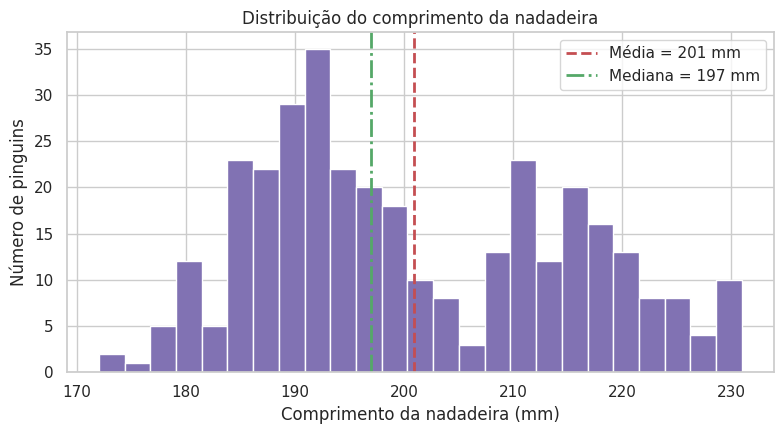

In [18]:
# ✅ SOLUÇÃO — Exercício 1 (verificação visual, opcional mas recomendada)
fig, ax = plt.subplots()
ax.hist(nadadeira, bins=25, color="#8172B3", edgecolor="white")
ax.axvline(media_nad,   color="#C44E52", linestyle="--", linewidth=2, label=f"Média = {media_nad:.0f} mm")
ax.axvline(mediana_nad, color="#55A868", linestyle="-.", linewidth=2, label=f"Mediana = {mediana_nad:.0f} mm")
ax.set_title("Distribuição do comprimento da nadadeira")
ax.set_xlabel("Comprimento da nadadeira (mm)")
ax.set_ylabel("Número de pinguins")
ax.legend()
plt.tight_layout()
plt.show()

### ✅ Interpretação esperada — Exercício 1

> O comprimento da nadadeira tem média de ≈ 200,9 mm e mediana de ≈ 197,0 mm, com desvio padrão de ≈ 14,1 mm (CV ≈ 7,0%). A média supera a mediana em quase 4 mm, indicando **assimetria à direita**: há um contingente de pinguins com nadadeiras longas puxando a média para cima. A contagem confirma — cerca de 45% dos indivíduos ficam acima da média e 55% abaixo, um desequilíbrio incompatível com uma distribuição simétrica.
>
> O histograma revela a causa: a distribuição é **bimodal**, exatamente como a da massa corporal. É a assinatura da mesma mistura de espécies. A interpretação honesta para a reunião é que **nenhuma medida-resumo única descreve bem esta variável** enquanto as espécies estiverem agregadas.

**A lição transferível:** média e mediana divergindo é um alarme barato. Ele não diz qual é o problema, mas diz que vale a pena olhar o histograma antes de reportar qualquer número.

### Exercício 2 — Análise comparativa entre grupos e comunicação do achado

**Contexto.** A mesma equipe voltou com uma pergunta mais fina:

> *"Existe diferença no bico entre machos e fêmeas dentro de cada espécie? E o padrão é o mesmo nas três espécies?"*

Esta é uma análise de **dois fatores** (espécie e sexo) e é o tipo de pergunta que aparece o tempo todo em projetos reais: recorte por segmento e por atributo simultaneamente.

**Tarefas:**

1. Filtre as linhas em que `sexo` está ausente (aqui a variável importa, então elas precisam sair).
2. Agrupe por `especie` **e** `sexo` e calcule n, média e desvio padrão de `comprimento_bico_mm`.
3. Calcule, para cada espécie, a **diferença absoluta** entre a média dos machos e a das fêmeas.
4. Produza um gráfico de barras agrupadas comparando as médias.
5. Escreva um parágrafo de achado seguindo a anatomia de 5 partes da seção 2.4.

In [19]:
# ===========================================
# Exercício 2 — ESQUELETO
# ===========================================

# 1) TODO: complete aqui — remova as linhas sem sexo registrado
df_sexo = ...

# 2) TODO: complete aqui — agrupe por especie E sexo, agregue comprimento_bico_mm
#    Dica: groupby aceita uma LISTA de colunas
resumo_bico = ...

print(resumo_bico)

# 3) TODO: complete aqui — diferença entre média dos machos e das fêmeas por espécie
#    Dica: .unstack() transforma o nível 'sexo' do índice em colunas
diferencas = ...

print("\nDiferença Macho - Fêmea (mm):")
print(diferencas)

Ellipsis

Diferença Macho - Fêmea (mm):
Ellipsis


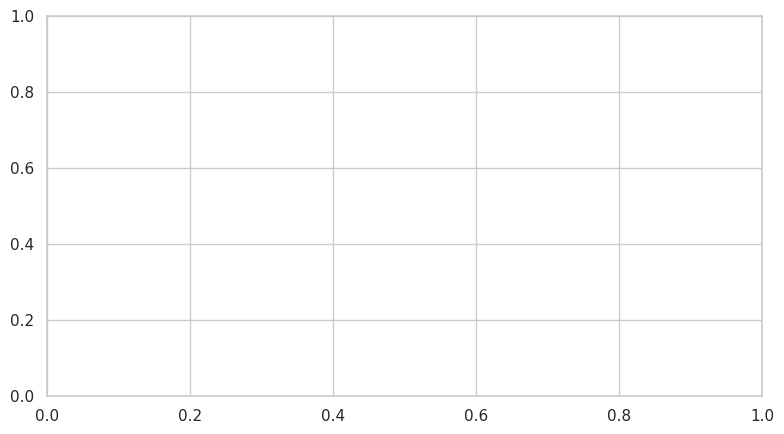

In [20]:
# ===========================================
# Exercício 2 — ESQUELETO do gráfico
# ===========================================
fig, ax = plt.subplots()

# TODO: complete aqui — monte a tabela médias[espécie][sexo] com .unstack()
medias = ...

x = np.arange(3)      # três posições no eixo, uma por espécie
largura = 0.35        # largura de cada barra

# TODO: complete aqui — desenhe duas séries de barras deslocadas de +-largura/2
# ax.bar(x - largura/2, ..., largura, label="Fêmea")
# ax.bar(x + largura/2, ..., largura, label="Macho")

# TODO: complete aqui — título, rótulos dos eixos, ticks com os nomes das espécies e legenda

plt.tight_layout()
plt.show()

### 💡 Dica — Exercício 2

- Para remover as linhas sem sexo: `df_limpo.dropna(subset=["sexo"]).copy()`.
- `groupby` aceita lista: `df_sexo.groupby(["especie", "sexo"], observed=True)["coluna"].agg(...)`. O parâmetro `observed=True` evita combinações vazias quando as colunas são do tipo `category`.
- O resultado tem **índice hierárquico** (espécie e sexo empilhados). `.unstack()` promove o nível mais interno a colunas, virando uma tabela retangular espécie × sexo — que é justamente o formato que o gráfico de barras precisa.
- Com essa tabela, `medias["Male"] - medias["Female"]` já devolve a diferença por espécie, elemento a elemento. Os rótulos de sexo no dataset original estão em inglês (`Male`, `Female`).
- Para posicionar barras agrupadas: desenhe a primeira em `x - largura/2` e a segunda em `x + largura/2`. Os ticks vão em `ax.set_xticks(x)` seguido de `ax.set_xticklabels(nomes)`.
- `ax.bar_label(barras, fmt="%.1f")` escreve o valor no topo de cada barra — sempre bem-vindo quando há poucas barras.

In [21]:
# ✅ SOLUÇÃO — Exercício 2 (parte 1: tabela)

# 1) Aqui o sexo é a variável de interesse, então os ausentes precisam sair.
df_sexo = df_limpo.dropna(subset=["sexo"]).copy()
print(f"Linhas usadas: {len(df_sexo)} (removidas {len(df_limpo) - len(df_sexo)} sem sexo)\n")

# 2) Agrupamento por dois fatores.
resumo_bico = (
    df_sexo
    .groupby(["especie", "sexo"], observed=True)["comprimento_bico_mm"]
    .agg(n="count", media="mean", desvio="std")
    .round(2)
)
print(resumo_bico)

# 3) unstack() transforma o nível 'sexo' em colunas -> tabela espécie x sexo.
medias = resumo_bico["media"].unstack()
diferencas = (medias["Male"] - medias["Female"]).round(2)

print("\nDiferença Macho - Fêmea no comprimento do bico (mm):")
print(diferencas)

Linhas usadas: 333 (removidas 9 sem sexo)

                   n  media  desvio
especie   sexo                     
Adelie    Female  73  37.26    2.03
          Male    73  40.39    2.28
Chinstrap Female  34  46.57    3.11
          Male    34  51.09    1.56
Gentoo    Female  58  45.56    2.05
          Male    61  49.47    2.72

Diferença Macho - Fêmea no comprimento do bico (mm):
especie
Adelie      3.13
Chinstrap   4.52
Gentoo      3.91
dtype: float64


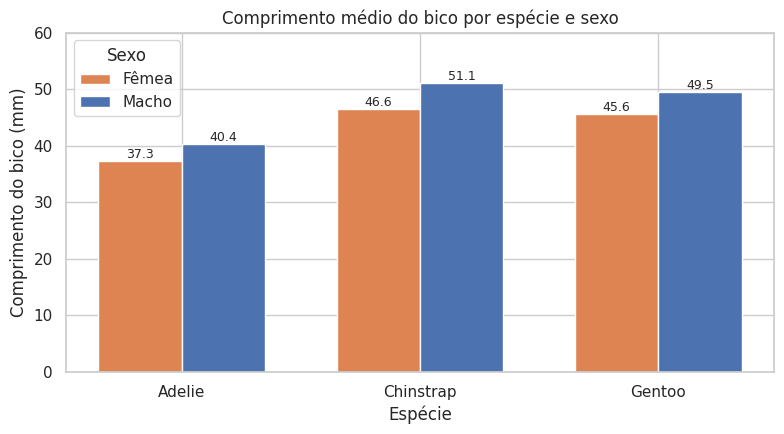

In [22]:
# ✅ SOLUÇÃO — Exercício 2 (parte 2: gráfico de barras agrupadas)

fig, ax = plt.subplots()

especies = medias.index.tolist()
x = np.arange(len(especies))
largura = 0.35

barras_f = ax.bar(x - largura/2, medias["Female"], largura,
                  label="Fêmea", color="#DD8452", edgecolor="white")
barras_m = ax.bar(x + largura/2, medias["Male"],   largura,
                  label="Macho", color="#4C72B0", edgecolor="white")

# Valor no topo de cada barra: elimina a necessidade de ler o eixo.
ax.bar_label(barras_f, fmt="%.1f", fontsize=9)
ax.bar_label(barras_m, fmt="%.1f", fontsize=9)

ax.set_title("Comprimento médio do bico por espécie e sexo")
ax.set_xlabel("Espécie")
ax.set_ylabel("Comprimento do bico (mm)")
ax.set_xticks(x)
ax.set_xticklabels(especies)
ax.set_ylim(0, 60)          # começar o eixo em zero: barras não mentem sobre proporção
ax.legend(title="Sexo")

plt.tight_layout()
plt.show()

### ✅ Interpretação esperada — Exercício 2

> Entre os 333 pinguins com sexo registrado, os machos apresentam bico mais longo que as fêmeas nas **três** espécies, sem exceção. A magnitude da diferença, porém, varia: ≈ 3,1 mm em Adelie, ≈ 4,6 mm em Gentoo e ≈ 5,0 mm em Chinstrap. O gráfico de barras agrupadas mostra o padrão como um degrau consistente, na mesma direção em todos os pares.
>
> Duas ressalvas honestas. Primeira: as diferenças entre sexos (3 a 5 mm) são pequenas diante das diferenças entre espécies — o bico do Adelie tem média de ≈ 39 mm contra ≈ 49 mm de Chinstrap e Gentoo. Segunda: o desvio padrão dentro de cada grupo é da ordem de 2,5 a 3,5 mm, comparável à própria diferença entre sexos, o que significa **sobreposição substancial** entre as distribuições de machos e fêmeas. A diferença de médias é real e consistente, mas não permite classificar um indivíduo pelo bico.
>
> Para a análise, isso sugere que espécie é o fator dominante e sexo é um efeito secundário porém sistemático, que vale controlar em modelos futuros.

**Sobre a decisão de fixar `ylim(0, 60)`.** Cortar o eixo y para começar perto de 38 mm faria a diferença entre as barras parecer enorme. É a distorção gráfica mais comum e mais fácil de cometer sem má-fé. Em gráficos de barra, cujo comprimento é a mensagem, o eixo começa em zero. Knaflic é categórica quanto a isso em *Storytelling com Dados*, e a regra vale para qualquer gráfico que saia deste notebook.

## 4. Desafio final — Relatório de uma página

**Situação.** A coordenação da estação de pesquisa vai apresentar os dados a um público não técnico e pediu **uma página** com o retrato do conjunto e a recomendação sobre como usá-lo. Você entrega um notebook que roda do zero e produz esse retrato.

### O que deve ser entregue

**Parte A — Perfil completo do dataset (código)**

Uma tabela-resumo, construída por você, com uma linha por variável numérica e colunas para: n, ausentes, média, mediana, desvio padrão, mínimo, máximo, IQR e coeficiente de variação. Sem copiar e colar quatro `describe()`: monte a tabela programaticamente, num laço ou com `agg`.

**Parte B — Investigação de relação entre variáveis (código)**

1. Calcule a matriz de correlação entre as quatro medidas corporais (`df_limpo[colunas_medida].corr()`).
2. Identifique o **par mais correlacionado** e produza um gráfico de dispersão desse par, **colorindo os pontos por espécie**.
3. Responda por escrito: a correlação forte que você encontrou no conjunto todo se mantém *dentro* de cada espécie, ou ela é outro efeito da mistura de grupos? Verifique calculando a correlação por espécie com `groupby`.

> Esta terceira pergunta é o coração do desafio. Ela reencena, com correlação, exatamente a armadilha que vimos com a média. Não conclua antes de calcular.

**Parte C — Achado principal (Markdown)**

Um parágrafo de 5 a 8 linhas, dirigido a um leitor não técnico, seguindo a anatomia de 5 partes da seção 2.4: contexto e n, achado quantificado, evidência visual citada, limite honesto, consequência prática. Sem jargão não explicado.

**Parte D — Reprodutibilidade**

Reinicie o kernel e execute tudo de cima a baixo. O notebook precisa rodar sem uma única célula de erro.

### Critérios de avaliação (10 pontos)

| Critério | Peso | O que se espera |
|---|---|---|
| Corretude técnica | 2,5 | Estatísticas corretas, sem erro de execução, decisões de limpeza declaradas |
| Qualidade do gráfico | 2,0 | Título, eixos rotulados com unidade, legenda legível, eixo não distorcido |
| Profundidade da análise | 2,5 | Parte B.3 respondida com cálculo, não com palpite; comparação agregado × por grupo |
| Interpretação escrita | 2,0 | Achado quantificado, linguagem acessível, limitação reconhecida |
| Organização e reprodutibilidade | 1,0 | Células curtas, Markdown explicando cada etapa, roda do zero |

**Bônus (até 1,0 ponto).** Refaça a Parte A com um dataset diferente de sua escolha entre os embutidos no seaborn (`sns.get_dataset_names()` lista as opções: `tips`, `titanic`, `diamonds`, `mpg` e outros). Aponte uma diferença relevante de qualidade dos dados em relação ao `penguins`.

## 5. Encerramento

### O que você praticou hoje

Você executou um fluxo completo de análise, do arquivo bruto ao achado escrito:

| Etapa | Ferramenta | O que produziu |
|---|---|---|
| Importar | `pd.read_csv` | DataFrame com 344 linhas |
| Inspecionar | `head`, `info`, `describe`, `isna` | Diagnóstico: 2 linhas sem medidas, 11 sem sexo |
| Limpar | `dropna(subset=)`, `astype("category")` | 342 linhas úteis, decisão justificada por escrito |
| Resumir | `mean`, `median`, `std`, `quantile`, `groupby` | CV agregado de 19% contra 8–10% por espécie |
| Visualizar | `hist`, `boxplot`, `bar` do Matplotlib | Bimodalidade evidente; Gentoo separado dos demais |
| Interpretar | Markdown | Achado quantificado com limitação declarada |

### As três ideias que ficam

1. **O agregado pode mentir por omissão.** A média de 4.202 g descrevia um pinguim que quase não existe. Foi o `groupby` que revelou a estrutura, e o histograma que a tornou óbvia. Sempre que houver uma variável categórica relevante, desagregue antes de concluir.

2. **Limpar é decidir, e decisão se documenta.** Removemos 2 linhas e mantivemos 11 outras, e ambas as escolhas estão escritas com o motivo. Um notebook auditável vale mais que um notebook esperto.

3. **Análise termina em frase, não em número.** Média, desvio e gráfico são insumos. O produto é a sentença que alguém consegue ler, entender e contestar.

### Ponte com a próxima aula

Repare no que aconteceu hoje: você tomou uma sequência de decisões — o que ler, o que remover, o que agrupar, como plotar, o que reportar — e cada uma delas foi improvisada no momento. Funcionou porque o dataset é pequeno e a pergunta era única.

Agora imagine essa mesma improvisação com dez fontes de dados, três analistas e seis meses de projeto. As dificuldades que você encontrou aqui — *"em que ordem eu faço isso?"*, *"quando é hora de parar de limpar?"*, *"o que exatamente eu entrego no fim?"* — não são falhas suas. São exatamente os problemas que motivaram a criação de **processos padronizados em ciência de dados**, tema da próxima aula.

Vamos estudar o **CRISP-DM** e modelos correlatos, que dão nome e ordem às etapas que hoje você percorreu no tato. Cada fase que veremos tem um equivalente direto numa célula deste notebook. Traga suas dúvidas de hoje: elas são o material da próxima discussão.

### Para consolidar

- **Grus**, *Data Science do Zero*, capítulo 5 (Estatística) e capítulo 9 (Obtendo Dados) — a base conceitual do que fizemos.
- **McKinney**, *Python para Análise de Dados* — a referência de `pandas`, escrita pelo criador da biblioteca.
- **Knaflic**, *Storytelling com Dados*, capítulos 1 e 2 — por que o eixo começa em zero e o que mais um gráfico honesto exige.